In [8]:
!pip install openpyxl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [openpyxl]━━ 1/2 [openpyxl]


In [15]:
input_folder = "/Users/kollybook/Library/Mobile Documents/com~apple~CloudDocs/Kolja_Hildenbrand/Uni/Master_Infectious_Diseases/Bartenschlager_internship/colocalisation_project/images/VeroE6_rep1/20260529_0154_bgsub/"
file = "20260529_0154_m1_m2_results.xlsx"

# Excel laden
df = pd.read_excel(input_folder + file)
df

,Combination,Channel 1,Channel 2,Time,Unnamed: 4
0,HA568_dsRNA488,0.0041,0.0133,12 h,12h_VeroE6_MOI5_HA568_dsRNA488_CS1_1
1,HA568_dsRNA488,0.0152,0.0049,12 h,12h_VeroE6_MOI5_HA568_dsRNA488_CS1_2
2,HA568_dsRNA488,0.0581,0.0435,12 h,12h_VeroE6_MOI5_HA568_dsRNA488_CS1_3
3,HA568_dsRNA488,0.1978,0.0231,12 h,12h_VeroE6_MOI5_HA568_dsRNA488_CS1_4
4,HA568_dsRNA488,0.0301,0.0075,12 h,12h_VeroE6_MOI5_HA568_dsRNA488_CS1_5
5,HA568_dsRNA488,0.0239,0.0171,12 h,12h_VeroE6_MOI5_HA568_dsRNA488_CS2_1
6,HA568_dsRNA488,0.0235,0.0175,12 h,12h_VeroE6_MOI5_HA568_dsRNA488_CS2_2
7,HA568_dsRNA488,0.0656,0.0288,12 h,12h_VeroE6_MOI5_HA568_dsRNA488_CS2_3
8,NS4B568_dsRNA488,0.0224,0.0599,12 h,12h_VeroE6_MOI5_NS4B568_dsRNA488_CS1_1
9,NS4B568_dsRNA488,0.0588,0.1418,12 h,12h_VeroE6_MOI5_NS4B568_dsRNA488_CS1_2


In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os


def plot_manders(
    file,
    input_folder,
    cell_type="Huh7",
    save=False,
    output_dir="",
    dpi=600,
    clean_labels=True
):
    output_dir=input_folder
    df = pd.read_excel(os.path.join(input_folder, file))

    plot_df = df.melt(
        id_vars=["Combination", "Time"],
        value_vars=["Channel 1", "Channel 2"],
        var_name="Channel",
        value_name="Manders"
    )

    def clean_name(x):
        if not clean_labels:
            return x
        return (
            x.replace("HA568", "HA")
             .replace("HA488", "HA")
             .replace("dsRNA488", "dsRNA")
             .replace("NS4B568", "NS4B")
        )

    def make_group_label(row):
        ch_a, ch_b = row["Combination"].split("_")

        ch_a = clean_name(ch_a)
        ch_b = clean_name(ch_b)

        if row["Channel"] == "Channel 1":
            return f"{ch_a} of {ch_b}"
        else:
            return f"{ch_b} of {ch_a}"

    plot_df["Group"] = plot_df.apply(make_group_label, axis=1)
    groups_order = []

    for combi in df["Combination"].drop_duplicates():
        ch_a, ch_b = combi.split("_")
    
        ch_a_clean = clean_name(ch_a)
        ch_b_clean = clean_name(ch_b)
    
        groups_order.append(f"{ch_a_clean} of {ch_b_clean}")  # Channel 1
        groups_order.append(f"{ch_b_clean} of {ch_a_clean}")  # Channel 2

    for time in plot_df["Time"].unique():

        sub = plot_df[plot_df["Time"] == time]

        fig, ax = plt.subplots(figsize=(8, 5))

        for idx, group in enumerate(groups_order):

            vals = sub.loc[
                sub["Group"] == group,
                "Manders"
            ].dropna().values

            if len(vals) == 0:
                continue

            jitter = np.random.normal(
                loc=0,
                scale=0.06,
                size=len(vals)
            )

            ax.scatter(
                np.full(len(vals), idx) + jitter,
                vals,
                facecolors="none",
                edgecolors="blue",
                linewidths=1,
                s=35,
                zorder=2
            )

            mean = np.mean(vals)
            sem = np.std(vals, ddof=1) / np.sqrt(len(vals))

            ax.errorbar(
                idx,
                mean,
                yerr=sem,
                fmt="_",
                color="black",
                capsize=4,
                markersize=20,
                linewidth=1.5,
                zorder=3
            )

        ax.set_xticks(np.arange(len(groups_order)))
        ax.set_xticklabels(
            groups_order,
            rotation=45,
            ha="right"
        )

        ax.set_ylabel(
            "Manders correlation coefficient (RM)",
            fontweight="bold"
        )

        ax.set_title(
            f"{cell_type} {time} h.p.i",
            fontsize=16,
            fontweight="bold"
        )

        ax.set_ylim(0, 1.05)

        plt.tight_layout()

        if save:
            os.makedirs(output_dir, exist_ok=True)

            filename = os.path.join(
                output_dir,
                f"{cell_type}_{time}_Manders_plot.png"
            )

            plt.savefig(
                filename,
                dpi=dpi,
                bbox_inches="tight"
            )

        plt.show()

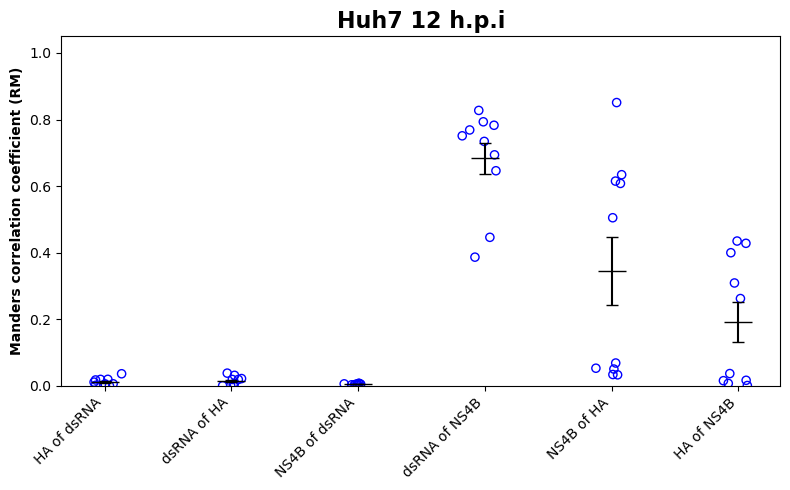

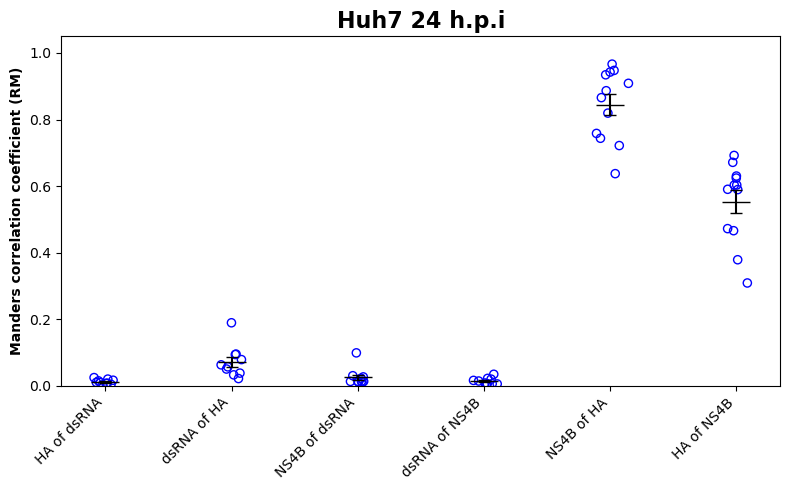

In [31]:
plot_manders(
    input_folder = "/Users/kollybook/Library/Mobile Documents/com~apple~CloudDocs/Kolja_Hildenbrand/Uni/Master_Infectious_Diseases/Bartenschlager_internship/colocalisation_project/images/Huh7_rep1/20260529_0137_bgsub/",
    file = "20260529_0137_m1_m2_results.xlsx",
    cell_type="Huh7",
    save=True
)